# Experimental Notebook for Vision Transformer Model for Art-Style Image Classification

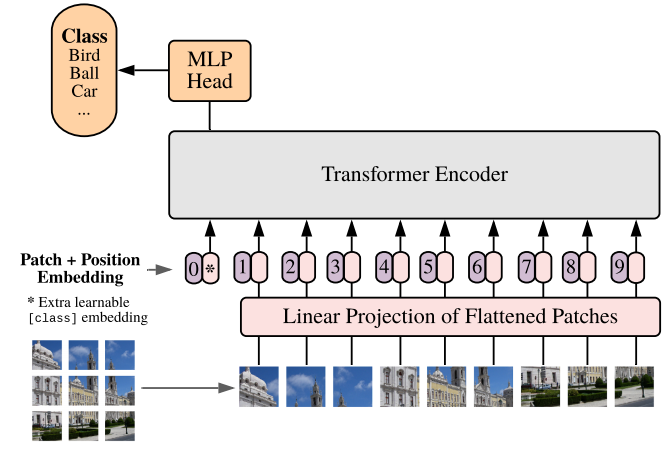

### Data Acquisition

In [ ]:
import os
import kagglehub
from pathlib import Path
from dotenv import load_dotenv

#define a local data dir (caching target)
LOCAL_DATA_DIR =  Path("./data/wikiart")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

def download_wikiart():
    """
    Downloads the WikiArt dataset via kagglehub only if not already cached.
    Returns the path to the dataset.
    """
    #check if we already have a marker file indicating a successful download
    marker = LOCAL_DATA_DIR / ".download_complete"

    if marker.exists():
        print("dataset already downloaded.skiping download")
        return str(LOCAL_DATA_DIR)

    #download the dataset
    print("downloading dataset from kagglehub (ipythonx/wikiart-gallery)")
    kagglehub_path = kagglehub.dataset_download("ipythonx/wikiart-gangogh-creating-art-gan")
    print(f"kagglehub cache path: {kagglehub_path}")

    #symlink or copy the contents into the local data dir
    src = Path(kagglehub_path)
    for item in src.iterdir():
        dest = LOCAL_DATA_DIR / item.name
        if not dest.exists():
            if item.is_dir():
                #use the symlink to save space - avoids copying large images files
                dest.symlink_to(item.resolve(), target_is_directory=True)
            else:
                dest.symlink_to(item.resolve())
    #create a marker file so that we dont download again
    marker.touch()
    print("download complete and cached at", str(LOCAL_DATA_DIR))
    return str(LOCAL_DATA_DIR)

#RUN
dataset_path = download_wikiart()
print("dataset root:", dataset_path)

### Data Exploration and Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from pathlib import Path
import random

#set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,6)

#discover style classes(usually they are subdirectories)
data_root = Path(dataset_path) / "images"
style_dirs = [d for d in data_root.iterdir() if d.is_dir() and not d.name.startswith(".")]
print(f"number of style classes: {len(style_dirs)}")
print("styles:",[d.name for d in style_dirs])

#lets count how many images are in each style_dir
class_counts = {}
all_image_paths = [] #for holding all images
for style_dir in style_dirs:
    images = list(style_dir.glob("*.*")) #all extensions
    #filter only images files
    images = [f for f in images if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}]
    class_counts[style_dir.name] = len(images)
    all_image_paths.extend(images)
print(f"total number of images: {len(all_image_paths)}")

#plot the class dist
plt.subplot(1,2,1)
sorted_counts = dict(sorted(class_counts.items(),key=lambda x: x[1],reverse=True))
bars = plt.bar(sorted_counts.keys(),sorted_counts.values())
plt.xticks(rotation=90,fontsize=8)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Style Class")
plt.tight_layout()

#add count labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

In [ ]:
#show imbalance metric: ratio max/min
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"max class size: {max_count} , min class size: {min_count},imbalance ratio: {imbalance_ratio}")

In [ ]:
from IPython.core.pylabtools import figsize
#visualize random samples from a few classes
sample_classes = random.sample(style_dirs,k=5)
fig,axes = plt.subplots(len(sample_classes),4,figsize=(16,3*len(sample_classes)))
for i,style_dir in enumerate(sample_classes):
    images = list(style_dir.glob("*.*"))
    images = [f for f in images if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}]
    chosen = random.sample(images,k=4)
    for j,img_path in enumerate(chosen):
        img = Image.open(img_path)
        axes[i,j].imshow(img)
        axes[i,j].axis("off")
        axes[i,j].set_title(style_dir.name)
plt.tight_layout()
plt.show()

In [ ]:
#image dimesnions analysis
sample_size = min(200, len(all_image_paths))
sampled_paths = random.sample(all_image_paths, k=sample_size)
widths, heights = [], []
for path in sampled_paths:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
    except Exception as e:
        print(f"error processing {path}: {e}")

#plot the distribution of widths, heights and aspect ratio
aspect_ratio = [w/h for w,h in zip(widths,heights)]
plt.subplot(1,3,1)
plt.hist(widths,bins=20,alpha=0.5,label="widths")
plt.legend()
plt.subplot(1,3,2)
plt.hist(heights,bins=20,alpha=0.5,label="heights")
plt.legend()
plt.subplot(1,3,3)
plt.hist(aspect_ratio,bins=20,alpha=0.5,label="aspect ratio")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Image dimension stats (sampled {len(widths)} images):")
print(f"  Width  - min:{min(widths)}, max:{max(widths)}, mean:{sum(widths)/len(widths):.1f}")
print(f"  Height - min:{min(heights)}, max:{max(heights)}, mean:{sum(heights)/len(heights):.1f}")

### Pytorch Dataset class submodulin/customizing for project

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np

#create a mapping from style name to integer label and reverse
style_names = sorted(list(class_counts.keys()))
style_to_label = {name: i for i, name in enumerate(style_names)}
label_to_style = {i: name for name, i in style_to_label.items()}
print(f"style_to_label: {style_to_label}")
print(f"label_to_style: {label_to_style}")

#build a list of all image_path,label pairs
all_samples = []
for style_dir in style_dirs:
    style_name = style_dir.name
    images = list(style_dir.glob("*.*"))
    label = label_to_style[style_to_label[style_name]]
    images = [f for f in images if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff'}]
    for img_path in images:
        all_samples.append((img_path,label))
print(f"total number of samples: {len(all_samples)}")

#train/validation split(stratified)
train_samples, val_samples = train_test_split(all_samples, test_size=0.2, random_state=42, stratify=[s[1] for s in all_samples])

IMG_SIZE = 224

train_transformations = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.4],std=[0.229,0.224,0.225])])

val_transformations = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.4],std=[0.229,0.224,0.225])])

#robust image loader that handles corrupted files
def pil_loader(path):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            return img
    except (OSError,IOError,SyntaxError):
        #return a black image placeholder if loading fails
        print(f"warning: corrupted image skipped->{path}")
        return Image.new("RGB",(IMG_SIZE,IMG_SIZE),(0,0,0))

class WikiArtDataset(Dataset):
    def __init__(self,samples,transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self,idx):
        img_path,label = self.samples[idx]
        img = pil_loader(img_path)
        if self.transform:
            image = self.transform(img)
            label = style_to_label[label]
        return image,label

train_dataset = WikiArtDataset(train_samples,transform=train_transformations)
val_dataset = WikiArtDataset(val_samples,transform=val_transformations)

batch_size = 128
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,pin_memory=False,num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=os.cpu_count(),pin_memory=False)

In [ ]:
def show_batch(dataloader,idx_to_label):
    images,labels = next(iter(dataloader))
    #denormalize
    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225],
        std=[1/0.229,1/0.224,1/0.225]
    )
    fig,axes = plt.subplots(1,4,figsize=(10,10))
    for i, ax in enumerate(axes.flat):
        img = inv_norm(images[i]).permute(1,2,0).numpy()
        img = np.clip(img,0,1)
        ax.imshow(img)
        ax.set_title(idx_to_label[labels[i].item()])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

#run
show_batch(train_loader,label_to_style)
print(f"Train loader: {len(train_loader)} batches, Val loader: {len(val_loader)} batches")

## Model Building Section

### Patch Embeddings layer

In [ ]:
import torch
import torch.nn as nn

class PatchEmbeddings(nn.Module):
    """
    Splits an image into fixed-size patches and linearly projects them.
    Uses a single Conv2d layer for efficient patch extraction + projection.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        """
        x: (B, C, H, W) -> (B, num_patches, embed_dim)
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [ ]:
# Quick sanity check
dummy_img = torch.randn(2, 3, 224, 224)   # batch of 2, RGB, 224x224
patch_embed = PatchEmbeddings(img_size=224, patch_size=16, embed_dim=768)
out = patch_embed(dummy_img)
print(f"Input shape: {dummy_img.shape}")
print(f"Output shape: {out.shape}")       # Expected: (2, 196, 768)
assert out.shape == (2, 196, 768), "Shape mismatch!"
print("Patch embedding works as expected.")

### Learnable positional embeddings with CLS token

In [ ]:
import torch
import torch.nn as nn

class PositionalEmbedding(nn.Module):
    """
    Adds a learnable CLS token and positional embeddings to patch tokens.
    """
    def __init__(self, num_patches,embed_dim):
        super(PositionalEmbedding, self).__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
    def forward(self,x):
        """
        x: (B, num_patches, embed_dim)
        """
        B = x.shape[0]
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embedding
        return x

In [ ]:
dummy_patches = torch.randn(2, 196, 768)  # output from patch embedding
pos_embedding = PositionalEmbedding(num_patches=196, embed_dim=768)
out = pos_embedding(dummy_patches)
print(f"Input patch tokens shape: {dummy_patches.shape}")
print(f"Output with CLS + pos embed shape: {out.shape}")  # Expected: (2, 197, 768)
assert out.shape == (2, 197, 768), "Positional embedding shape mismatch!"
print("Positional embeddings + CLS token added correctly.")

### Encoder Block

In [ ]:
import torch
import torch.nn as nn

class EncoderBlock(nn.Module):
    """
    Transformer encoder block with multi-head attention and feed-forward layers.
    """
    def __init__(self, embed_size, heads, mlp_ratio=4.0,dropout=0.1):
        super(EncoderBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.attention = nn.MultiheadAttention(embed_dim=embed_size, num_heads=heads,
                                               dropout=dropout,batch_first=True)
        mlp_hidden = int(embed_size * mlp_ratio)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, embed_size),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        """
        x: (B, num_patches, embed_dim)
        """
        residual_1 = x
        x = self.norm1(x)
        x, _ = self.attention(x, x, x)
        x = residual_1 + x
        residual_2 = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = residual_2 + x
        return x

class TransformerEncoder(nn.Module):
    """Stacks multiple EncoderBlock layers."""
    def __init__(self,embed_size,depth,heads,mlp_ratio=4.0,dropout=0.1):
        super(TransformerEncoder, self).__init__()
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_size, heads, mlp_ratio, dropout) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_size)
    def forward(self, x):
        """
        x: (B, num_patches, embed_dim)
        """
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x

In [ ]:
dummy_tokens = torch.randn(2, 197, 768)  # (B, seq_len, embed_dim)
encoder = TransformerEncoder(embed_size=768, heads=12, depth=6, mlp_ratio=4.0, dropout=0.1)
out = encoder(dummy_tokens)
print(f"Input token shape: {dummy_tokens.shape}")
print(f"Output token shape: {out.shape}")  # Expected: (2, 197, 768)
assert out.shape == dummy_tokens.shape, "Encoder output shape must match input."
print("Transformer encoder works correctly.")

### Vision Transformer Classification Head and Full model

In [ ]:
import torch
import torch.nn as nn

class VisionTransformer(nn.Module):
    """
    Vision Transformer (ViT) built from scratch:
    - Patch embedding (Conv2d)
    - Learnable CLS token + positional embeddings
    - Transformer encoder (stack of EncoderBlocks)
    - Classification head (uses CLS token or global average pooling)
    """
    def __init__(self,img_size=224,
                 patch_size=16,
                 in_channels=3,
                 embed_dim=768,
                 depth=6,
                 heads=12,
                 mlp_ratio=4.0,
                 num_classes=1000,
                 dropout=0.1,
                 use_cls_token=True):
        super(VisionTransformer,self).__init__()
        self.use_cls_token = use_cls_token
        self.patch_embed = PatchEmbeddings(img_size,patch_size,in_channels,embed_dim)
        self.encoder = TransformerEncoder(embed_dim,depth,heads,mlp_ratio,dropout)
        num_patches = self.patch_embed.n_patches

        #class token
        if use_cls_token:
            self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
            self.pos_embed = nn.Parameter(torch.randn(1,num_patches+1,embed_dim))
        else:
            self.pos_embed = nn.Parameter(torch.randn(1,num_patches,embed_dim))
            self.cls_token = None

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim,num_classes)

        #weight initiliazation (truncated normal for ps_embed and cls_token)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        if self.use_cls_token:
            nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self,x):
        """
        x: (B, C, H, W)
        """
        x = self.patch_embed(x)

        if self.use_cls_token:
            B = x.shape[0]
            cls_tokens = self.cls_token.expand(B, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm(x)

        if self.use_cls_token:
            #use the CLS token output (first position)
            x = x[:, 0]
        else:
            #global average
            x = x.mean(dim=1)
        x = self.head(x)
        return x


In [ ]:
vit_tiny = VisionTransformer(
    img_size=224, patch_size=16, num_classes=27,   # 27 styles
    embed_dim=192, depth=12, heads=3, mlp_ratio=4.0, dropout=0.1
)
dummy_input = torch.randn(1, 3, 224, 224)
logits = vit_tiny(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output logits shape: {logits.shape}")  # Expected: (1, 27)
assert logits.shape == (1, 27), "Output shape mismatch!"
print("Full Vision Transformer works correctly.")

In [ ]:
!pip install torchinfo torchsummary timm -q

In [ ]:
#lets see model summary, showing input shape, output shape trainable, etc
from torchsummary import summary
from torchinfo import summary
dummy_input = torch.randn(1, 3, 224, 224)
summary(vit_tiny,input_size=(1,3,224,224),col_names=["input_size","output_size","num_params","trainable"],row_settings=["var_names"])

### Loss function  with class weight and optional label smoothing

In [ ]:
import torch.nn as nn
import torch
from collections import Counter

#compute the class weights (inverse frequency) to handle imbalance

train_labels = [label for _, label in train_samples]
class_counts = Counter(train_labels)
total_samples = len(train_labels)
class_weights = {label: total_samples / count for label, count in class_counts.items()}

#inverse frequency: weight[c] = total_samples / (num_classes * count[c])

class_weights_list = []

for c in range(len(class_counts.keys())):
    count_c = class_counts.get(c,1)
    weight_c = total_samples / (len(class_counts.keys()) * count_c)
    class_weights_list.append(weight_c)

class_weights_tensor = torch.tensor(class_weights_list,dtype=torch.float32)
print("class weights (first 5):",class_weights_tensor[:5])

#standard criterion is the CrossEntropyLoss with class weights
criterion_ce = nn.CrossEntropyLoss(weight=class_weights_tensor)


#optional use of crossentropy with lable smoothing

class LabelSmoothingCrossEntropy(nn.Module):
    """
    Cross-entropy loss with label smoothing.
    Smoothing factor applies uniform distribution over non-target classes.
    """
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, pred, target):
        log_probs = torch.log_softmax(pred, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1)).squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

#use the standard weighted cross-entropy by default
criterion = criterion_ce
print("loss function ready: Cross Entropy loss with class weights")

#test how the loss function works
dummy_logits = torch.randn(4, len(class_counts.keys()))
dummy_labels = torch.randint(0, len(class_counts.keys()), (4,))
loss_val = criterion(dummy_logits, dummy_labels)
print(f"Test loss value: {loss_val:.4f}")

### Training Loop

In [ ]:
import time
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import matplotlib.pyplot as plt

#setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

model = VisionTransformer(
    img_size=224, patch_size=16, num_classes=len(class_counts.keys()),   # 27 styles
    embed_dim=192, depth=12, heads=3, mlp_ratio=4.0, dropout=0.1
).to(device)

#loss and optmizer
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)
optimizer = optim.AdamW(model.parameters(),lr=3e-4,weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer,T_max=10,eta_min=1e-6)

#traininf hyperparameters
EPOCHS = 10
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}

#training loop
for epoch in range(EPOCHS):
    print(f"\n{"="*40} Epoch {epoch+1}/{EPOCHS} {"="*40}")

    #train phase
    model.train()
    train_loss = 0.0
    train_total = 0
    train_correct = 0
    start_time = time.time()
    pbar = tqdm(train_loader,desc=f"Epoch {epoch+1}/{EPOCHS} - Training")
    for images,labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()

        #accumulate metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += preds.eq(labels).sum().item()
        train_total += labels.size(0)

        #update progress bar
        pbar.set_postfix({"loss":loss.item(),"acc":train_correct/train_total})
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = 100.0 * train_correct / train_total

    #validation phase
    model.eval()
    val_loss = 0.0
    val_total = 0
    val_correct = 0
    with torch.no_grad():
        pbar = tqdm(val_loader,desc=f"Epoch {epoch+1}/{EPOCHS} - Validation")
        for images,labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)

            #accumulate metrics
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)
            pbar.set_postfix({"loss":loss.item(),"acc":val_correct/val_total})
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = 100.0 * val_correct / val_total

    #scheduler step
    scheduler.step()

    #store history
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")
    print(f"Learning rate: {scheduler.get_last_lr()[0]:.2e}")

    #overfitting check
    if epoch_val_loss > 1.5 * epoch_train_loss:
        print("Overfitting detected!")
        #break (this will control overfitting by stopping the training for the criteria above)

    #save best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f"New best model saved (val_acc={best_val_acc:.2f}%)")

        torch.save(best_model_wts,"best_model.pth")
        print("Best model weights saved.")
#load model weights
model.load_state_dict(best_model_wts)
print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.2f}%")
print("\nBest model weights loaded.")

### Model training visualizations

In [ ]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(history["train_loss"],label="train loss")
ax1.plot(history["val_loss"],label="val loss")
ax1.set_title("loss over epochs")
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.legend()

ax2.plot(history["train_acc"],label="train acc")
ax2.plot(history["val_acc"],label="val acc")
ax2.set_title("accuracy over epochs")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#move model to eval mode
model.eval()

all_preds = []
all_labels = []
all_probs = [] #store probabilities for topk

with torch.no_grad():
    pbar = tqdm(val_loader,desc="Evaluating")
    for images,labels in pbar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs,dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        pbar.set_postfix({"acc":accuracy_score(all_labels,all_preds)})

#concatenate all probabilities
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

#top-1 accuracy
top1_acc = accuracy_score(all_labels, all_preds)
print(f"Top-1 Accuracy: {top1_acc * 100:.2f}%")

#topk accuracy(k=5)
k=5
topk_indices = np.argsort(all_probs,axis=1)[:,-k:] #shape (N,k)
topk_correct = np.any(topk_indices == all_labels.reshape(-1,1),axis=1)
topk_acc = topk_correct.mean()
print(f"Top-{k} Accuracy: {topk_acc * 100:.2f}%")

#classification report
target_names = [label_to_style[i] for i in range(len(class_counts.keys()))]
report = classification_report(all_labels, all_preds, target_names=target_names,digits=2,zero_division=1)
print("\nClassification report:\n")
print(report)

#confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('Confusion Matrix')
plt.show()

#per class accuracy (from confusion matrix)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

#sort by accuracy for a quick view of hardest/easiest classes
sorted_idx = np.argsort(per_class_acc)
print("\nPer-class accuracy (sorted):")
for idx in sorted_idx:
    print(f"{target_names[idx]}: {per_class_acc[idx] * 100:.2f}%")



In [ ]:
#visualize the per class accuracy sorted
plt.figure(figsize=(10,5))
plt.bar(target_names,per_class_acc[sorted_idx])
plt.xlabel("Accuracy")
plt.xticks(rotation=90)
plt.title("Per-class accuracy (sorted)")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from torchvision import transforms
import io
import sys


def predict_and_visualize_random_samples(model, val_dataset, label_to_style, device, num_samples=3, seed=None):
    """
    Samples random images from the validation dataset, predicts their classes,
    and visualizes the results with top-1 and top-5 predictions.

    Args:
        model (torch.nn.Module): The trained model.
        val_dataset (torch.utils.data.Dataset): The validation dataset.
        label_to_style (dict): A dictionary mapping integer labels to style names.
        device (torch.device): The device (CPU or CUDA) to run inference on.
        num_samples (int, optional): The number of random images to display. Defaults to 3.
        seed (int, optional): A seed for reproducibility. If None, samples will vary.

    Returns:
        matplotlib.figure.Figure: The generated matplotlib figure.
        str: A string containing all printed prediction details.
    """
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)
        np.random.seed(seed)

    model.eval()

    # Denormalization function for displaying images
    inv_norm = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    # Randomly select indices from the validation dataset
    total_val_samples = len(val_dataset)
    if num_samples > total_val_samples:
        print(f"Warning: num_samples ({num_samples}) is greater than total validation samples ({total_val_samples}). Using all available samples.")
        sampled_indices = random.sample(range(total_val_samples), total_val_samples)
    else:
        sampled_indices = random.sample(range(total_val_samples), num_samples)

    sampled_images_list = []
    sampled_labels_list = []

    for idx in sampled_indices:
        image, label = val_dataset[idx] # This returns an already transformed image and its label
        sampled_images_list.append(image)
        sampled_labels_list.append(label)

    # Stack them into a batch and move to device
    sampled_images_batch = torch.stack(sampled_images_list).to(device)
    sampled_labels_batch = torch.tensor(sampled_labels_list).to(device)

    with torch.no_grad():
        outputs = model(sampled_images_batch)
        probs = torch.softmax(outputs, dim=1)

        _, top1_preds = torch.max(outputs, 1)
        top5_probs, top5_indices = torch.topk(probs, k=5, dim=1)

    fig, axes = plt.subplots(1, num_samples, figsize=(6 * num_samples, 8)) # Increased height from 6 to 8
    if num_samples == 1: # Handle case of a single subplot for a single image
        axes = [axes]

    # Capture print statements
    old_stdout = sys.stdout
    redirected_output = io.StringIO()
    sys.stdout = redirected_output

    print("\n--- Model Predictions on Sampled Images ---")
    for i in range(num_samples):
        img_display = inv_norm(sampled_images_list[i]).permute(1, 2, 0).cpu().numpy()
        img_display = np.clip(img_display, 0, 1) # Clip to [0,1] for proper display

        actual_class_name = label_to_style[sampled_labels_batch[i].item()]
        predicted_class_name_top1 = label_to_style[top1_preds[i].item()]

        # Check if actual class is in top-5 predictions
        top5_class_names = [label_to_style[idx.item()] for idx in top5_indices[i]]
        is_in_top5 = " (in Top-5)" if actual_class_name in top5_class_names else " (NOT in Top-5)"

        axes[i].imshow(img_display)
        axes[i].axis("off")
        axes[i].set_title(f"Actual: {actual_class_name}\nPredicted (Top-1): {predicted_class_name_top1}{is_in_top5}")

        print(f"\nImage {i+1}:")
        print(f"  Actual Class: {actual_class_name}")
        print(f"  Top-1 Predicted Class: {predicted_class_name_top1}")
        print(f"  Top-5 Predictions:")
        for j in range(5):
            prob = top5_probs[i, j].item()
            idx = top5_indices[i, j].item()
            class_name = label_to_style[idx]
            print(f"    {j+1}. {class_name} (Prob: {prob:.4f})")

    plt.tight_layout()

    # Restore stdout and get the captured text
    sys.stdout = old_stdout
    output_text = redirected_output.getvalue()

    return fig, output_text

# Example usage:
# predict_and_visualize_random_samples(model, val_dataset, label_to_style, device, num_samples=3)
# To get the same images each time, use a seed:
# predict_and_visualize_random_samples(model, val_dataset, label_to_style, device, num_samples=3, seed=42)

# For direct execution without Gradio, you can still call it and show the plot
# fig, text = predict_and_visualize_random_samples(model, val_dataset, label_to_style, device, num_samples=3)
# plt.show()

### Dummy deployment with Gradio

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr

# Define a wrapper function for Gradio
def gradio_predict_wrapper(num_samples, seed_input):
    # Gradio text input will be a string, convert to int or None
    actual_seed = int(seed_input) if seed_input else None

    # Call the modified function which now returns a figure and captured text
    fig, output_text = predict_and_visualize_random_samples(model, val_dataset, label_to_style, device, num_samples, actual_seed)

    return fig, output_text

# Create the Gradio interface
iface = gr.Interface(
    fn=gradio_predict_wrapper,
    inputs=[
        gr.Slider(minimum=1, maximum=10, value=3, step=1, label="Number of Samples"),
        gr.Textbox(label="Optional Seed (leave blank for random)", type="text", placeholder="Enter an integer seed")
    ],
    outputs=[
        gr.Plot(label="Sampled Images and Predictions"),
        gr.Textbox(label="Prediction Details", lines=15)
    ],
    title="Art Style Classifier: Vision Transformer (ViT) Demo",
    description="Select the number of random images from the validation set to visualize, and optionally provide a seed for reproducibility."
)

# Launch the interface
# Set share=True to get a public link, which is useful in Colab.
# Set debug=True for more detailed console output during development.
iface.launch(share=True, debug=True)